---
## Scetion 0: Initial setup

**Imports**

In [1]:
# Imports
import sys
from pathlib import Path

# This notebook only orchestrates. Every function and class it calls lives in the
# `macrocircuits` package under src/ -- read or edit it there.
SRC = str(Path.cwd().parent / 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import matplotlib.pyplot as plt
from dm_control import suite  # needed directly here (not just via macrocircuits) to call suite.load() ourselves for the sanity checks below

# test_dm_control is normally only used in the tutorial notebook's exploration section,
# but we need it here too to visually confirm the new evasion/foraging tasks actually work.
from macrocircuits import ensure_tonic, test_dm_control

# Clones neuromatch/tonic next to this notebook (once) and puts it on the import path.
# Must run before the tonic-backed imports below (training, models).
ensure_tonic()

from macrocircuits.training import play_model, train
# ppo_mlp_model is referenced by name inside the quoted strings passed to train() below,
# so it needs to be a real, importable name in this notebook's namespace.
from macrocircuits.models import ppo_mlp_model
from macrocircuits.plotting import plot_performance


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


---
## Scetion 1: Select parameters

**Parameters**
- Networks used
- Length of the swimmer
- RL Method used
- ...?

In [ ]:
# Parameters

In [2]:
# Sanity check only
# Confirms Emmanuel's obstacle-spawning code actually places obstacles
# correctly and the worm can physically interact with them.
env = suite.load('swimmer', 'evasion', task_kwargs={'random': 1, 'n_obstacles': 10})
test_dm_control(env)

In [3]:
# Sanity check only but for the foraging task: confirms food
# actually appears and that it's positioned somewhere the worm can reach.
env = suite.load('swimmer', 'foraging', task_kwargs={'random': 1})
test_dm_control(env)

---
## Scetion 2: Training

**Training**

In [4]:
# Training - Obstacle Avoidance (MLP baseline only).
# NCAP is skipped here, the plan is to replace it with a fixed, non-learned formula instead,
# but that hasn't been built yet. 
# n_obstacles=10 matches what Emmanuel used in his run.
train('import tonic.torch',
      'tonic.torch.agents.PPO(model=ppo_mlp_model(actor_sizes=(256, 256), critic_sizes=(256,256)))',
      'tonic.environments.ControlSuite("swimmer-evasion", task_kwargs=dict(n_obstacles=10))',
      name = 'mlp_256_evasion',
      trainer = 'tonic.Trainer(steps=int(5e5),save_steps=int(1e5))')


c:\Users\User\Desktop\Neuromatch\neuroai-macrocircuits\.venv\Lib\site-packages\gym\spaces\box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Config file saved to data\local\experiments\tonic\swimmer-evasion\mlp_256_evasion\config.yaml
          Time left:  epoch 0:00:00  total 1:02:04          
actor                                                       
  clip fraction                                        0.121
  entropy                                               1.05
  iterations                                            41.8
  kl                                                 0.00792
  loss                                               -0.0147
  std                                                  0.689
  stop                                                 0.012
critic                                                      
  iterations                                              80
  loss                                                  39.7
  v                                                    -20.3
test                                                        
  action                                            

In [5]:
# Training - Foraging (MLP baseline only), same reasoning as above: NCAP still needs
# some component to turn sensed food-direction into a turn signal: non-learned replacement for Emmanuel's MLP_controller yet.
train('import tonic.torch',
      'tonic.torch.agents.PPO(model=ppo_mlp_model(actor_sizes=(256, 256), critic_sizes=(256,256)))',
      'tonic.environments.ControlSuite("swimmer-foraging")',
      name = 'mlp_256_foraging',
      trainer = 'tonic.Trainer(steps=int(5e5),save_steps=int(1e5))')


c:\Users\User\Desktop\Neuromatch\neuroai-macrocircuits\.venv\Lib\site-packages\gym\spaces\box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Config file saved to data\local\experiments\tonic\swimmer-foraging\mlp_256_foraging\config.yaml
          Time left:  epoch 0:00:00  total 0:28:23          
actor                                                       
  clip fraction                                        0.138
  entropy                                               1.05
  iterations                                              23
  kl                                                 0.00667
  loss                                                -0.015
  std                                                  0.691
  stop                                                0.0326
critic                                                      
  iterations                                              80
  loss                                                  2.72
  v                                                     5.72
test                                                        
  action                                          

---
## Scetion 3: Visualization

**Visualization of the rewards and the behaviour**

In [4]:
# Visualization

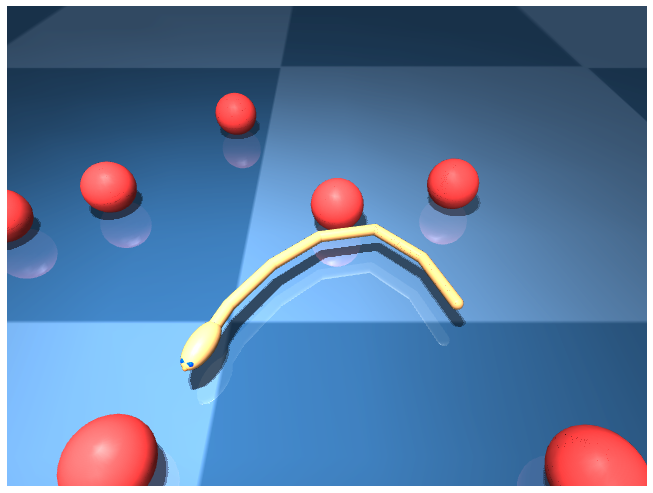

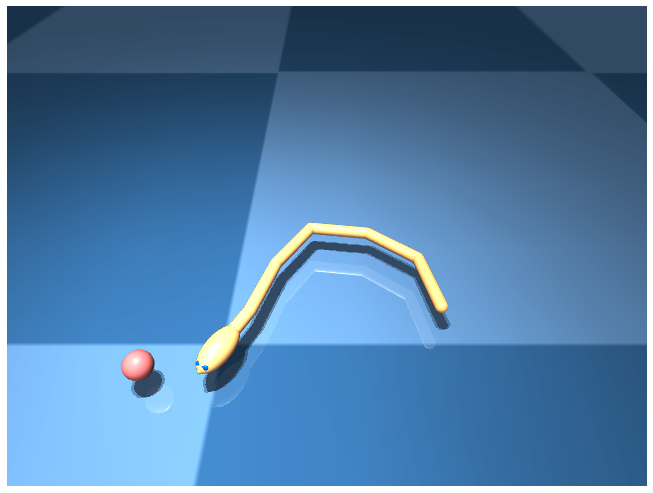

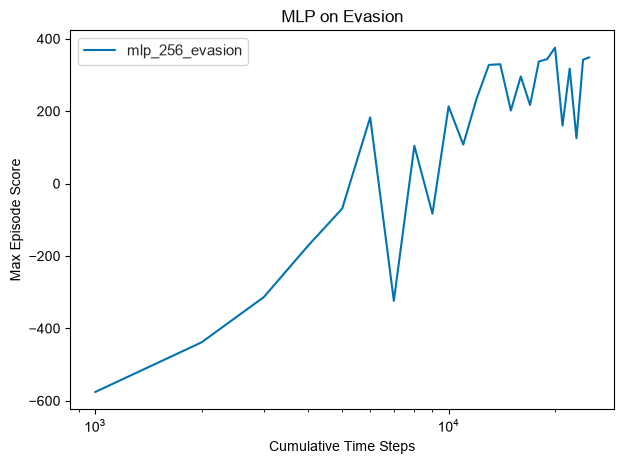

In [6]:
# Learning curve for the evasion run above. The path must exactly match
# data/local/experiments/tonic/<environment-name>/<name=...> from the training cell.
%matplotlib inline
fig, ax = plt.subplots()
plot_performance(['data/local/experiments/tonic/swimmer-evasion/mlp_256_evasion'], ax=ax, title='MLP on Evasion')
plt.tight_layout()
plt.show()


In [7]:
# Loads the last saved checkpoint from the evasion run and renders a video of it
play_model('data/local/experiments/tonic/swimmer-evasion/mlp_256_evasion')

c:\Users\User\Desktop\Neuromatch\neuroai-macrocircuits\.venv\Lib\site-packages\gym\spaces\box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")



Loading weights from data/local/experiments/tonic/swimmer-evasion/mlp_256_evasion\checkpoints\step_500000.pt
Reward for the run:  40.914974


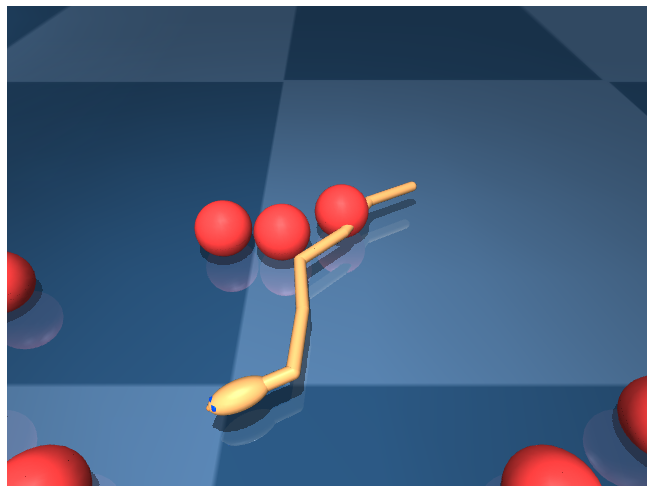

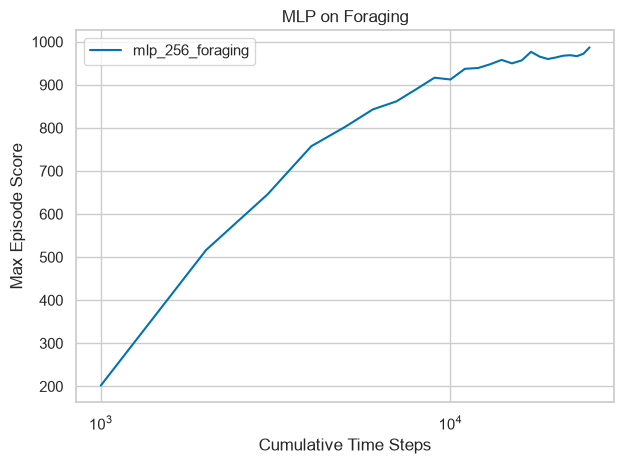

In [8]:
# Same as above, for the foraging run.
%matplotlib inline
fig, ax = plt.subplots()
plot_performance(['data/local/experiments/tonic/swimmer-foraging/mlp_256_foraging'], ax=ax, title='MLP on Foraging')
plt.tight_layout()
plt.show()

In [9]:
play_model('data/local/experiments/tonic/swimmer-foraging/mlp_256_foraging')

c:\Users\User\Desktop\Neuromatch\neuroai-macrocircuits\.venv\Lib\site-packages\gym\spaces\box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")



Loading weights from data/local/experiments/tonic/swimmer-foraging/mlp_256_foraging\checkpoints\step_500000.pt
Reward for the run:  955.1838
